In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("traffic.csv")
df['DateTime'] = pd.to_datetime(df['DateTime'])

df.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [3]:
df['hour'] = df['DateTime'].dt.hour
df['day'] = df['DateTime'].dt.day
df['month'] = df['DateTime'].dt.month
df['day_of_week'] = df['DateTime'].dt.dayofweek

df.head()

,DateTime,Junction,Vehicles,ID,hour,day,month,day_of_week
0,2015-11-01 00:00:00,1,15,20151101001,0,1,11,6
1,2015-11-01 01:00:00,1,13,20151101011,1,1,11,6
2,2015-11-01 02:00:00,1,10,20151101021,2,1,11,6
3,2015-11-01 03:00:00,1,7,20151101031,3,1,11,6
4,2015-11-01 04:00:00,1,9,20151101041,4,1,11,6


In [4]:
df['hour'] = df['DateTime'].dt.hour
df['day'] = df['DateTime'].dt.day
df['month'] = df['DateTime'].dt.month
df['day_of_week'] = df['DateTime'].dt.dayofweek

df.head()

,DateTime,Junction,Vehicles,ID,hour,day,month,day_of_week
0,2015-11-01 00:00:00,1,15,20151101001,0,1,11,6
1,2015-11-01 01:00:00,1,13,20151101011,1,1,11,6
2,2015-11-01 02:00:00,1,10,20151101021,2,1,11,6
3,2015-11-01 03:00:00,1,7,20151101031,3,1,11,6
4,2015-11-01 04:00:00,1,9,20151101041,4,1,11,6


In [5]:
def traffic_level(v):
    if v < 20:
        return 0   # Low
    elif v < 40:
        return 1   # Medium
    else:
        return 2   # High

df['Traffic_Level'] = df['Vehicles'].apply(traffic_level)

df[['Vehicles','Traffic_Level']].head()

,Vehicles,Traffic_Level
0,15,0
1,13,0
2,10,0
3,7,0
4,9,0


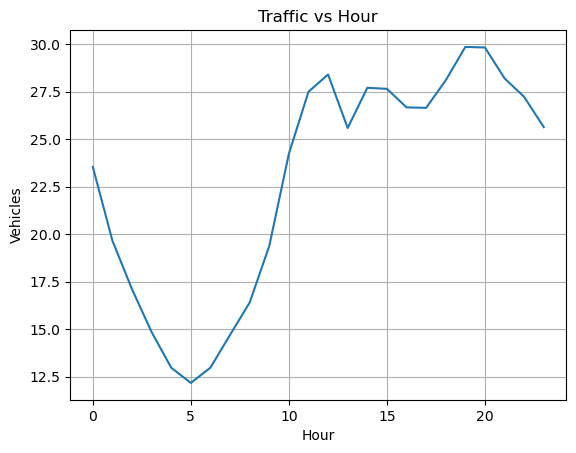

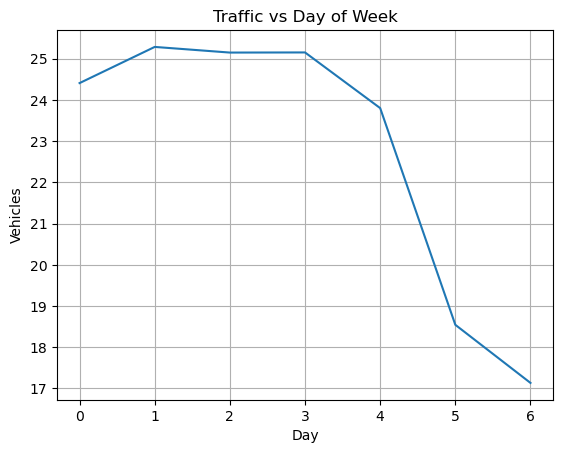

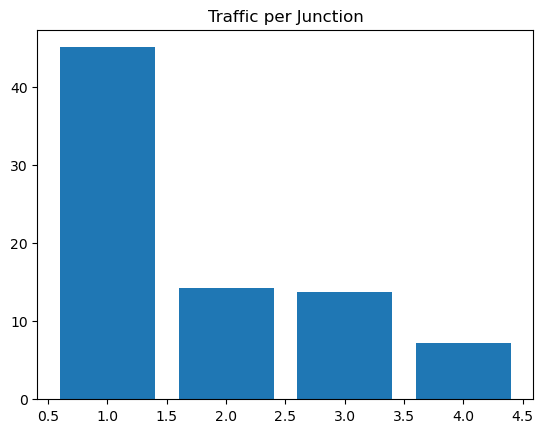

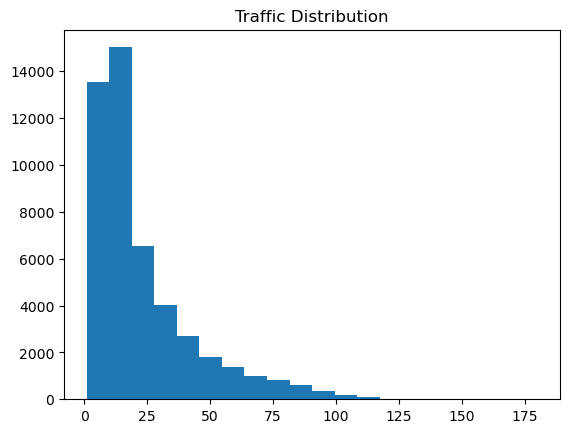

In [6]:
# Traffic vs Hour
hourly = df.groupby('hour')['Vehicles'].mean()
plt.figure()
plt.plot(hourly.index, hourly.values)
plt.title("Traffic vs Hour")
plt.xlabel("Hour")
plt.ylabel("Vehicles")
plt.grid()
plt.show()

# Traffic vs Day
dow = df.groupby('day_of_week')['Vehicles'].mean()
plt.figure()
plt.plot(dow.index, dow.values)
plt.title("Traffic vs Day of Week")
plt.xlabel("Day")
plt.ylabel("Vehicles")
plt.grid()
plt.show()

# Junction Traffic
junction = df.groupby('Junction')['Vehicles'].mean()
plt.figure()
plt.bar(junction.index, junction.values)
plt.title("Traffic per Junction")
plt.show()

# Distribution
plt.figure()
plt.hist(df['Vehicles'], bins=20)
plt.title("Traffic Distribution")
plt.show()

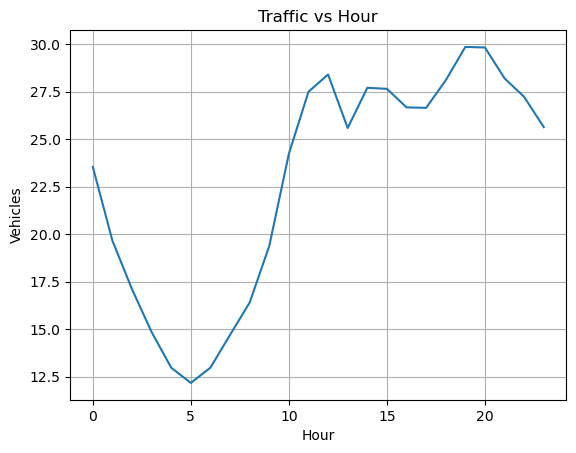

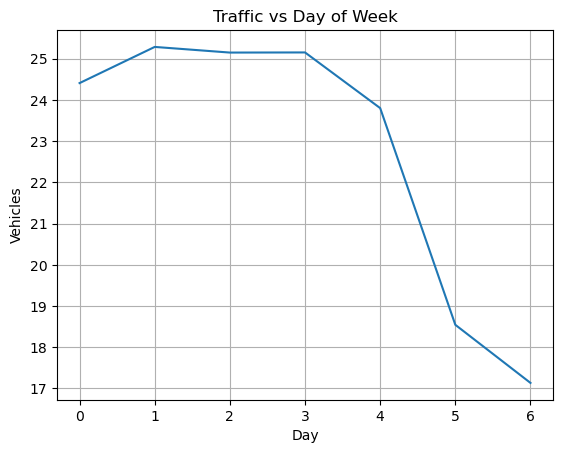

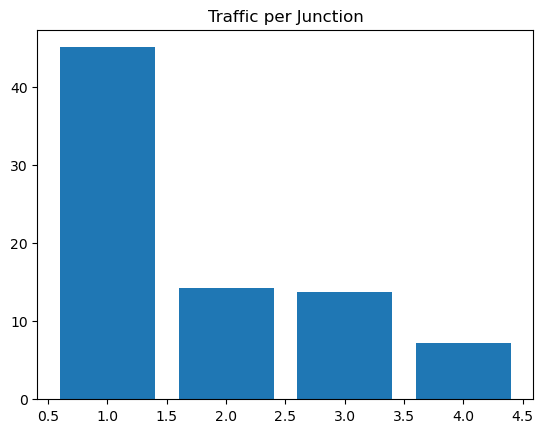

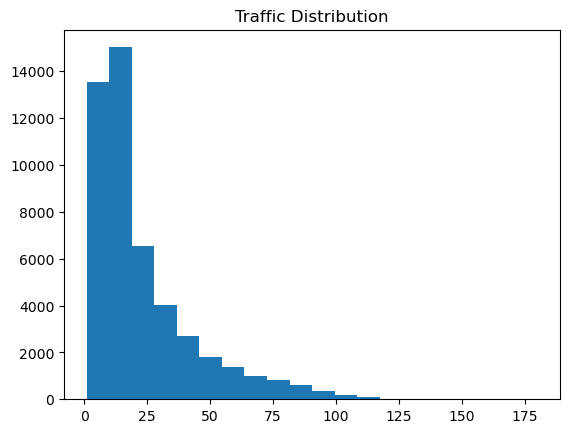

In [8]:
X = df[['hour', 'day', 'month', 'day_of_week', 'Junction']]
y = df['Traffic_Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

RandomForestClassifier()

In [9]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8259559434746467

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.92      5974
           1       0.65      0.59      0.62      2102
           2       0.74      0.75      0.74      1548

    accuracy                           0.83      9624
   macro avg       0.76      0.76      0.76      9624
weighted avg       0.82      0.83      0.82      9624



Confusion Matrix:
 [[5544  354   76]
 [ 522 1238  342]
 [  67  314 1167]]


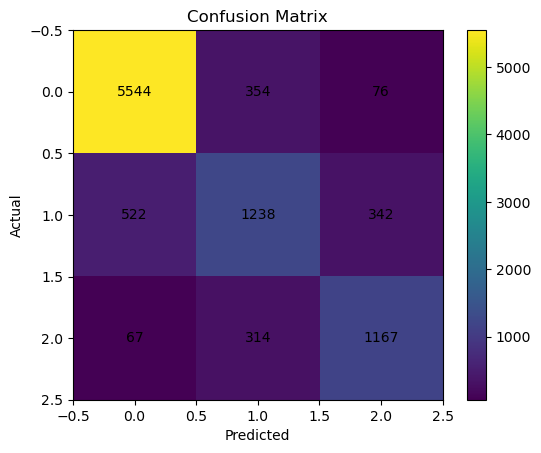

In [10]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.colorbar()
plt.show()

In [11]:
G = nx.Graph()

junctions = df['Junction'].unique()

# Add nodes
for j in junctions:
    G.add_node(j)

# Create connections
for i in range(len(junctions)-1):
    G.add_edge(junctions[i], junctions[i+1])

if len(junctions) > 2:
    G.add_edge(junctions[0], junctions[-1])

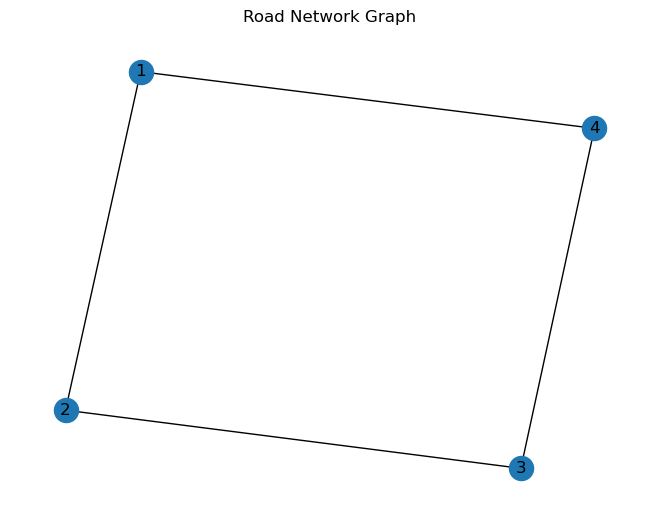

In [12]:
plt.figure()
nx.draw(G, with_labels=True)
plt.title("Road Network Graph")
plt.show()

In [13]:
# Example inputs (change anytime)
source = junctions[0]
destination = junctions[-1]

hour = 18
day = 10
month = 5
dow = 2

# Assign weights
for u, v in G.edges():
    pred = model.predict([[hour, day, month, dow, u]])[0]

    if pred == 0:
        weight = 10
    elif pred == 1:
        weight = 20
    else:
        weight = 30

    G[u][v]['weight'] = weight

# Find route
path = nx.dijkstra_path(G, source=source, target=destination, weight='weight')
cost = nx.dijkstra_path_length(G, source=source, target=destination, weight='weight')

print("Best Route:", path)
print("Total Cost:", cost)

if cost < 30:
    print("Traffic: LOW")
elif cost < 60:
    print("Traffic: MEDIUM")
else:
    print("Traffic: HIGH")

Best Route: [1, 4]
Total Cost: 30
Traffic: MEDIUM


c:\Users\deepa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\deepa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\deepa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\deepa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
